First specify where your output files live, having run the `gai_cal.py` command.

In [13]:
output_dir = "my_output/GGMP"

Now we can read in the age predictions data, which should live in a generated file called `result.tsv`.

In [15]:
import pandas as pd

age_results_df = pd.read_csv(f"{output_dir}/result.tsv", sep="\t")
age_results_df.head(20)

,id,age,health,raw GAI,adjust value,corrected GAI
0,11757.G440205594.56280,97,n,-34.8966,-4.5471,-30.3495
1,11757.G440981236.56280,93,n,-33.0152,-4.5471,-28.4681
2,11757.G440282442.56280,90,n,-22.1406,-4.5471,-17.5934
3,11757.G441802240.56280,90,n,-41.0738,-4.5471,-36.5267
4,11757.G440104362.56280,89,n,-53.5171,-4.5471,-48.9700
5,11757.G440883449.56280,89,y,-11.6803,-4.5471,-7.1332
6,11757.G441802124.56280,89,n,-26.1447,-4.5471,-21.5975
7,11757.G441802333.56280,89,n,-40.4602,-4.5471,-35.9131
8,11757.G441303020.56280,89,y,-9.4231,-4.5471,-4.8759
9,11757.G440981433.56280,89,n,-33.5803,-4.5471,-29.0332


At this point, you might note anybody whose age falls in the range [40, 45) years will have an adjusted value of `NaN`; this is due to a bug in the (fragile) definition of the age bands: this interval is missing, but may be fixed later.

A simple logistic regression or t-test (in the paper, they use "gradient descent" to find the optimal threshold) will give us an accuracy score, balanced accuracy or AUC.

In [16]:
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

# 1) Prepare analysis data (drop rows impacted by missing corrected GAI)
analysis_df = age_results_df[["health", "corrected GAI"]].copy()
analysis_df = analysis_df.dropna(subset=["corrected GAI", "health"]).copy()
analysis_df["y"] = (analysis_df["health"] == "n").astype(int)  # non-healthy = 1

n_total = len(age_results_df)
n_used = len(analysis_df)
n_dropped = n_total - n_used
class_counts = analysis_df["y"].value_counts().sort_index()

print(f"Rows in result.tsv: {n_total}")
print(f"Rows used for analysis: {n_used}")
print(f"Rows dropped (missing corrected GAI/health): {n_dropped}")
print("Class counts (0=healthy, 1=non-healthy):")
print(class_counts.to_string())

# 2) Distribution summary and significance test
healthy_vals = analysis_df.loc[analysis_df["y"] == 0, "corrected GAI"].to_numpy()
nonhealthy_vals = analysis_df.loc[analysis_df["y"] == 1, "corrected GAI"].to_numpy()

summary = analysis_df.groupby("y")["corrected GAI"].agg([
    "count", "mean", "median", "std", "min", "max"
])
summary.index = ["healthy (0)", "non-healthy (1)"]
print("\nCorrected GAI summary by class:")
print(summary.round(4))

u_stat, p_value = mannwhitneyu(nonhealthy_vals, healthy_vals, alternative="two-sided")
rank_biserial = (2 * u_stat) / (len(nonhealthy_vals) * len(healthy_vals)) - 1
print("\nMann-Whitney U test (non-healthy vs healthy):")
print(f"U statistic = {u_stat:.2f}, p-value = {p_value:.3e}")
print(f"Rank-biserial effect size = {rank_biserial:.4f}")

# 3) Cross-validated threshold optimization for two methods
X = analysis_df["corrected GAI"].to_numpy()
y = analysis_df["y"].to_numpy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def fold_metrics_from_labels(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "ba": balanced_accuracy_score(y_true, y_pred),
        "sensitivity": sens,
        "specificity": spec,
    }

# Method A: direct corrected GAI threshold.
# Direction is inferred so larger transformed scores always indicate non-healthy risk.
direction = 1.0 if nonhealthy_vals.mean() >= healthy_vals.mean() else -1.0
X_direct_score = direction * X
thr_direct = np.linspace(X_direct_score.min(), X_direct_score.max(), 201)
mean_ba_direct = []

for t in thr_direct:
    fold_bas = []
    for _, test_idx in cv.split(X.reshape(-1, 1), y):
        y_val = y[test_idx]
        y_pred = (X_direct_score[test_idx] >= t).astype(int)
        fold_bas.append(balanced_accuracy_score(y_val, y_pred))
    mean_ba_direct.append(np.mean(fold_bas))

best_i_direct = int(np.argmax(mean_ba_direct))
best_thr_direct = float(thr_direct[best_i_direct])

# Evaluate Method A at best threshold across folds
direct_fold_metrics = []
direct_fold_aucs = []
direct_oof_scores = np.zeros_like(X, dtype=float)
for _, test_idx in cv.split(X.reshape(-1, 1), y):
    y_val = y[test_idx]
    score_val = X_direct_score[test_idx]
    pred_val = (score_val >= best_thr_direct).astype(int)
    direct_fold_metrics.append(fold_metrics_from_labels(y_val, pred_val))
    direct_fold_aucs.append(roc_auc_score(y_val, score_val))
    direct_oof_scores[test_idx] = score_val

# Map threshold back to original corrected GAI scale for interpretability.
best_thr_direct_gai = best_thr_direct / direction

# Method B: logistic regression + probability threshold search
thr_prob = np.linspace(0, 1, 201)
mean_ba_prob = []

for t in thr_prob:
    fold_bas = []
    for train_idx, test_idx in cv.split(X.reshape(-1, 1), y):
        X_train = X[train_idx].reshape(-1, 1)
        y_train = y[train_idx]
        X_val = X[test_idx].reshape(-1, 1)
        y_val = y[test_idx]

        lr = LogisticRegression(solver="lbfgs", max_iter=1000)
        lr.fit(X_train, y_train)
        prob_val = lr.predict_proba(X_val)[:, 1]
        y_pred = (prob_val >= t).astype(int)
        fold_bas.append(balanced_accuracy_score(y_val, y_pred))
    mean_ba_prob.append(np.mean(fold_bas))

best_i_prob = int(np.argmax(mean_ba_prob))
best_thr_prob = float(thr_prob[best_i_prob])

# Evaluate Method B at best threshold across folds + collect OOF probabilities
logit_fold_metrics = []
logit_fold_aucs = []
logit_oof_probs = np.zeros_like(X, dtype=float)
coef_vals = []
intercept_vals = []

for train_idx, test_idx in cv.split(X.reshape(-1, 1), y):
    X_train = X[train_idx].reshape(-1, 1)
    y_train = y[train_idx]
    X_val = X[test_idx].reshape(-1, 1)
    y_val = y[test_idx]

    lr = LogisticRegression(solver="lbfgs", max_iter=1000)
    lr.fit(X_train, y_train)
    prob_val = lr.predict_proba(X_val)[:, 1]
    pred_val = (prob_val >= best_thr_prob).astype(int)

    logit_fold_metrics.append(fold_metrics_from_labels(y_val, pred_val))
    logit_fold_aucs.append(roc_auc_score(y_val, prob_val))
    logit_oof_probs[test_idx] = prob_val

    coef_vals.append(lr.coef_[0, 0])
    intercept_vals.append(lr.intercept_[0])

# Aggregate helper

def mean_std(metrics_list, key):
    vals = np.array([m[key] for m in metrics_list], dtype=float)
    return float(np.nanmean(vals)), float(np.nanstd(vals, ddof=1))

# Build comparison table
comparison_rows = []

ba_m, ba_s = mean_std(direct_fold_metrics, "ba")
sens_m, sens_s = mean_std(direct_fold_metrics, "sensitivity")
spec_m, spec_s = mean_std(direct_fold_metrics, "specificity")
auc_m = float(np.mean(direct_fold_aucs))
auc_s = float(np.std(direct_fold_aucs, ddof=1))
comparison_rows.append({
    "method": "A: direct GAI threshold",
    "best_threshold": best_thr_direct_gai,
    "balanced_accuracy_mean": ba_m,
    "balanced_accuracy_std": ba_s,
    "auc_mean": auc_m,
    "auc_std": auc_s,
    "sensitivity_mean": sens_m,
    "specificity_mean": spec_m,
})

ba_m, ba_s = mean_std(logit_fold_metrics, "ba")
sens_m, sens_s = mean_std(logit_fold_metrics, "sensitivity")
spec_m, spec_s = mean_std(logit_fold_metrics, "specificity")
auc_m = float(np.mean(logit_fold_aucs))
auc_s = float(np.std(logit_fold_aucs, ddof=1))
comparison_rows.append({
    "method": "B: logistic + prob threshold",
    "best_threshold": best_thr_prob,
    "balanced_accuracy_mean": ba_m,
    "balanced_accuracy_std": ba_s,
    "auc_mean": auc_m,
    "auc_std": auc_s,
    "sensitivity_mean": sens_m,
    "specificity_mean": spec_m,
})

comparison_df = pd.DataFrame(comparison_rows).sort_values("balanced_accuracy_mean", ascending=False)
pd.set_option("display.precision", 4)

print("\nMethod comparison (5-fold stratified CV):")
print(comparison_df.to_string(index=False))

winner = comparison_df.iloc[0]
paper_baseline = 0.67
status = "above" if winner["balanced_accuracy_mean"] > paper_baseline else "below"
print(
    f"\nBest method: {winner['method']} | "
    f"BA={winner['balanced_accuracy_mean']:.4f} +/- {winner['balanced_accuracy_std']:.4f} | "
    f"AUC={winner['auc_mean']:.4f} +/- {winner['auc_std']:.4f}"
)
print(
    f"Compared with paper baseline BA~0.67: this is {status} by "
    f"{abs(winner['balanced_accuracy_mean'] - paper_baseline):.4f}."
)

# Implied corrected GAI cutoff for logistic model using mean coefficients
mean_coef = float(np.mean(coef_vals))
mean_intercept = float(np.mean(intercept_vals))
if abs(mean_coef) > 1e-10 and 0 < best_thr_prob < 1:
    logit_p = np.log(best_thr_prob / (1 - best_thr_prob))
    implied_gai_cutoff = (logit_p - mean_intercept) / mean_coef
    print(f"Mean logistic slope = {mean_coef:.4f}, intercept = {mean_intercept:.4f}")
    print(f"Implied corrected GAI cutoff at best prob threshold: {implied_gai_cutoff:.4f}")
else:
    print("Implied corrected GAI cutoff for logistic model is unstable (coef or threshold edge case).")

Rows in result.tsv: 6242
Rows used for analysis: 5799
Rows dropped (missing corrected GAI/health): 443
Class counts (0=healthy, 1=non-healthy):
y
0    1082
1    4717

Corrected GAI summary by class:
                 count    mean  median      std      min      max
healthy (0)       1082  0.0000 -0.0405   3.4805 -12.2817  14.4272
non-healthy (1)   4717 -5.8131 -5.8249  11.3271 -48.9700  38.7799

Mann-Whitney U test (non-healthy vs healthy):
U statistic = 1604444.00, p-value = 3.996e-81
Rank-biserial effect size = -0.3713

Method comparison (5-fold stratified CV):
                      method  best_threshold  balanced_accuracy_mean  balanced_accuracy_std  auc_mean  auc_std  sensitivity_mean  specificity_mean
     A: direct GAI threshold         -5.5338                  0.7298                 0.0076    0.6856   0.0121            0.5094            0.9501
B: logistic + prob threshold          0.8350                  0.7294                 0.0060    0.6856   0.0121            0.5132         

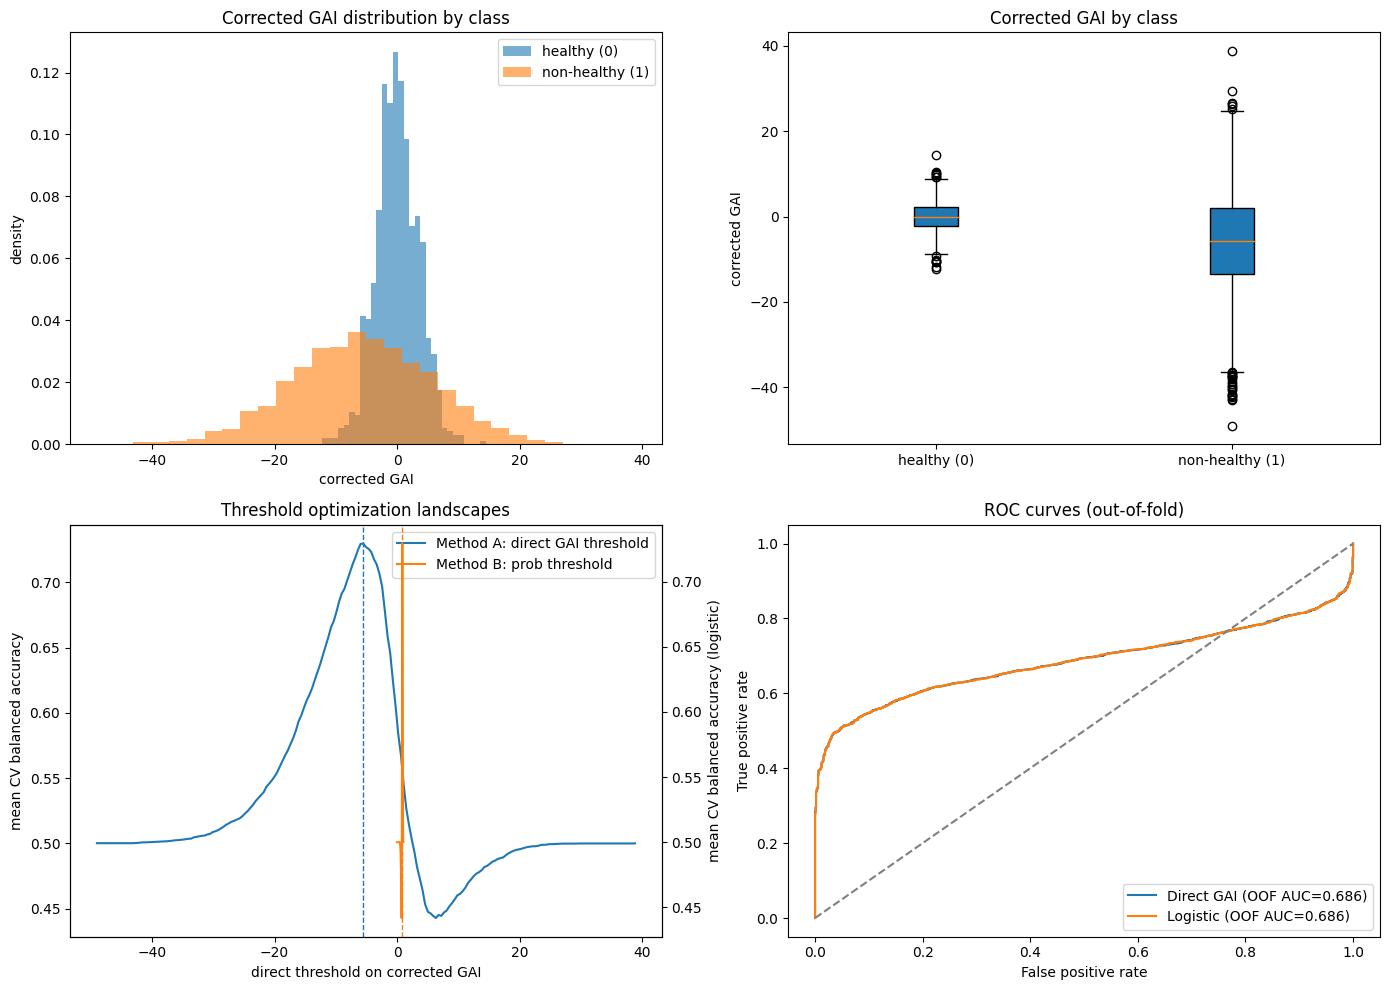


Note: missing corrected GAI values are likely due to the known missing [40,45) age bin in gai_cal.py.


In [ ]:
# 4) Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Distribution plot
axes[0, 0].hist(healthy_vals, bins=30, alpha=0.6, label="healthy (0)", density=True)
axes[0, 0].hist(nonhealthy_vals, bins=30, alpha=0.6, label="non-healthy (1)", density=True)
axes[0, 0].set_title("Corrected GAI distribution by class")
axes[0, 0].set_xlabel("corrected GAI")
axes[0, 0].set_ylabel("density")
axes[0, 0].legend()

# (b) Boxplot
axes[0, 1].boxplot(
    [healthy_vals, nonhealthy_vals],
    labels=["healthy (0)", "non-healthy (1)"],
    patch_artist=True,
)
axes[0, 1].set_title("Corrected GAI by class")
axes[0, 1].set_ylabel("corrected GAI")

# (c) BA vs threshold curves
axes[1, 0].plot(thr_direct / direction, mean_ba_direct, label="Method A: direct GAI threshold")
axes[1, 0].axvline(best_thr_direct_gai, linestyle="--", linewidth=1)
axes[1, 0].set_xlabel("direct threshold on corrected GAI")
axes[1, 0].set_ylabel("mean CV balanced accuracy")

ax2 = axes[1, 0].twinx()
ax2.plot(thr_prob, mean_ba_prob, color="tab:orange", label="Method B: prob threshold")
ax2.axvline(best_thr_prob, color="tab:orange", linestyle="--", linewidth=1)
ax2.set_ylabel("mean CV balanced accuracy (logistic)")
axes[1, 0].set_title("Threshold optimization landscapes")

# Combined legend for twin axis
lines1, labels1 = axes[1, 0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1, 0].legend(lines1 + lines2, labels1 + labels2, loc="best")

# (d) ROC curves using out-of-fold scores
fpr_d, tpr_d, _ = roc_curve(y, direct_oof_scores)
fpr_l, tpr_l, _ = roc_curve(y, logit_oof_probs)
auc_direct_oof = roc_auc_score(y, direct_oof_scores)
auc_logit_oof = roc_auc_score(y, logit_oof_probs)

axes[1, 1].plot(fpr_d, tpr_d, label=f"Direct GAI (OOF AUC={auc_direct_oof:.3f})")
axes[1, 1].plot(fpr_l, tpr_l, label=f"Logistic (OOF AUC={auc_logit_oof:.3f})")
axes[1, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 1].set_title("ROC curves (out-of-fold)")
axes[1, 1].set_xlabel("False positive rate")
axes[1, 1].set_ylabel("True positive rate")
axes[1, 1].legend(loc="lower right")

plt.tight_layout()